# Hierarchial Audio Classification Using Deep Learning

## Section 0: Imports & Configurations

### Configurations

In [1]:
DATASET = "urbansound8k" # Choose any available dataset from the 'soundata' library
SPECTROGRAM_METHOD = "Mel" # Choose a spectrogram representation: 'STFT', 'Mel', 'MFCCs'

### Import modules

In [2]:
import soundata
import librosa
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
import ast

### Download Dataset
NOTE: If you already have "DATASET" downloaded and verified, you can skip running this section

In [3]:
dataset = soundata.initialize(DATASET)
if not dataset:
    dataset.download()  # download the dataset
    dataset.validate()  # validate that all the expected files are there

## Section 1: Preprocessing of data

### Tagging of Data

#### Urbansound
Urbansound does not include a hierachical structure, hence we define our own.

In [4]:
urbansound_id_dict = {0 : "air_conditioner",1 : "car_horn",2 : "children_playing",3 : "dog_bark",4 : "drilling",5 :"engine_idling",6 : "gun_shot",7 : "jackhammer",8 : "siren",9 : "street_music"}

# Define Hierachy structure
hierarchy_US = {
    "human_animal" : [
        {"human": ["children_playing", "street_music"]},
        {"animal": ["dog_bark"]} ],

    "vehicle" : [
        {"vehicle_operation": ["engine_idling"]},
        {"vehicle_signal": ["car_horn", "siren"]}],

    "mechanical": [
        {"construction_tools": ["drilling", "jackhammer"]},
        {"machinery": ["air_conditioner"]}],

    "impact": [
        {"hazardous": ["gun_shot"]}]
    }





#### Hierarchy label functions

All data will have the hierachical label structure defined as a list: ```hierarchy = [level_1, level_2, ..., level_n]```
- Where the lowest index labels the most coarse level, and the highest index labels the finest level.

In [6]:
def build_label_paths(hierarchy):
    """
    Build mapping: fine_label -> full hierarchy path

    returns: 
        a dictionary with the finest label as the key,
        that points to a list with each index corresponding to the hierarchy label on depth "i"
    """

    label_to_path = {}

    def traverse(node, path):
        if isinstance(node, dict):
            for key, value in node.items():
                traverse(value, path + [key])

        elif isinstance(node, list):
            for item in node:
                traverse(item, path)

        elif isinstance(node, str):
            # leaf node (actual class)
            label_to_path[node] = path + [node]

    traverse(hierarchy, [])
    return label_to_path


def get_max_depth(label_paths):
    return max(len(p) for p in label_paths.values())


def encode_hierarchy(label, label_paths, max_depth):
    """
    Convert label into padded hierarchy levels
    (Automatically pads paths, if the hiearchy does not have equal length along the whole path)
    """
    path = label_paths.get(label, [None])

    # pad to max depth
    padded = path + [None] * (max_depth - len(path))
    return padded

In [7]:
# Choose a hierachy structure
hierarchy = hierarchy_US 

label_paths = build_label_paths(hierarchy) # Returns unpadded label paths -> for fine levels only
max_depth = get_max_depth(label_paths) # Retrieve max depth of the hierarchy (Used for padding)

# Output hierarchy index path for a fine level.
hierarchy_structure = encode_hierarchy(label="dog_bark", label_paths=label_paths, max_depth=max_depth)
print(hierarchy_structure)

['human_animal', 'animal', 'dog_bark']


#### Write Data to CSV
Meta data, will include: Hierachical Label structure 

In [8]:
# Output folder
out_dir = Path("metadata")
out_dir.mkdir(parents=True, exist_ok=True)

def write_csv(output_path, rows):
    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} clips to: {output_path}")

# Save Datasets to CSV
if DATASET == "urbansound8k":
    output_path = out_dir / "urbansound8k_metadata.csv"
    label_paths = build_label_paths(hierarchy_US)
    max_depth = get_max_depth(label_paths)

    rows = []
    for clip_id in dataset.clip_ids:
        clip = dataset.clip(clip_id)

        rows.append({
            "clip_id": clip.clip_id,
            "class_id": clip.class_id,
            "freesound_start_time": clip.freesound_start_time,
            "freesound_end_time": clip.freesound_end_time,
            "salience": clip.salience,
            "slice_file_name": clip.slice_file_name,
            
            "class_label": clip.class_label,
            "hierarchy": encode_hierarchy(label= clip.class_label, label_paths=label_paths, max_depth=max_depth)
        })
    write_csv(output_path, rows)


Saved 8732 clips to: metadata\urbansound8k_metadata.csv


### Data Visualization and Statistics

#### Utility functions for data visualization

In [9]:
def load_with_parsed_hierarchy(csv_path):
    """ 
    Only returns the "hierarchy" column from the meta dataset
    
    """
    df = pd.read_csv(csv_path)
    
    # Convert string → list
    df["hierarchy"] = df["hierarchy"].apply(ast.literal_eval)
    
    return df

def count_by_hierarchy_level(df, level, normalized=False):
    """
    Count occurrences of labels at a given hierarchy level
    
    Args:
        df: pandas DataFrame
        level: int (e.g. 0, 1, 2)
        
    Returns:
        pandas Series (label -> count)
    """
    
    def get_level(h):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    counts = df["hierarchy"].apply(get_level).value_counts(dropna=True)
    if normalized:
        total = sum(counts)
        counts = counts / total
    
    return counts

def plot_hierarchy_distribution(counts, level, sort=True):
    """
    Plot histogram of hierarchy counts
    
    Args:
        counts: pandas Series from count_by_hierarchy_level
        level: int (for labeling)
        sort: sort bars descending
    """
    
    if sort:
        counts = counts.sort_values(ascending=False)

    plt.figure()
    counts.plot(kind="bar")
    
    plt.title(f"Hierarchy Level {level} Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

def stacked_distribution(df, level_parent, level_child):
    """
    Create a pivot table for stacked plotting
    
    Args:
        df: DataFrame with parsed hierarchy
        level_parent: int (e.g. 0)
        level_child: int (e.g. 1)
        
    Returns:
        pivot table (parent x child counts)
    """

    def get_level(h, level):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    temp = pd.DataFrame({
        "parent": df["hierarchy"].apply(lambda h: get_level(h, level_parent)),
        "child": df["hierarchy"].apply(lambda h: get_level(h, level_child)),
    })

    pivot = pd.crosstab(temp["parent"], temp["child"])

    return pivot

def plot_stacked_distribution(pivot, normalize=False):
    """
    Plot stacked bar chart
    
    Args:
        pivot: DataFrame from stacked_distribution
        normalize: if True, show proportions instead of counts
    """

    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0)

    pivot.plot(kind="bar", stacked=True)

    plt.title("Stacked Hierarchy Distribution")
    plt.xlabel("Parent Level")
    plt.ylabel("Proportion" if normalize else "Count")
    plt.xticks(rotation=45, ha="right")

    plt.legend(title="Child Level", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


#### Histograms pr. hierarchy level 

Use the tools to assess the class imbalance

The section below allows for 2D plots:

hierarchy
human_animal    3000
mechanical      3000
vehicle         2358
impact           374
Name: count, dtype: int64


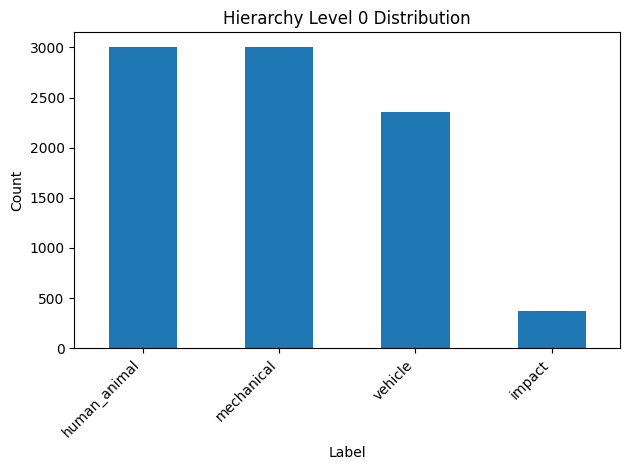

hierarchy
human                 2000
construction_tools    2000
vehicle_signal        1358
machinery             1000
vehicle_operation     1000
animal                1000
hazardous              374
Name: count, dtype: int64


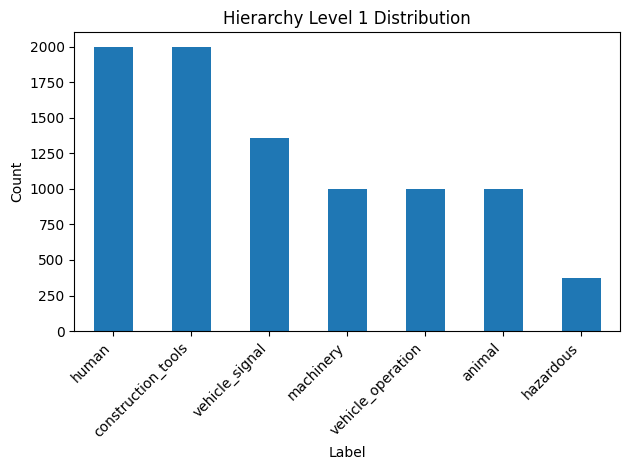

hierarchy
children_playing    1000
air_conditioner     1000
jackhammer          1000
drilling            1000
engine_idling       1000
dog_bark            1000
street_music        1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


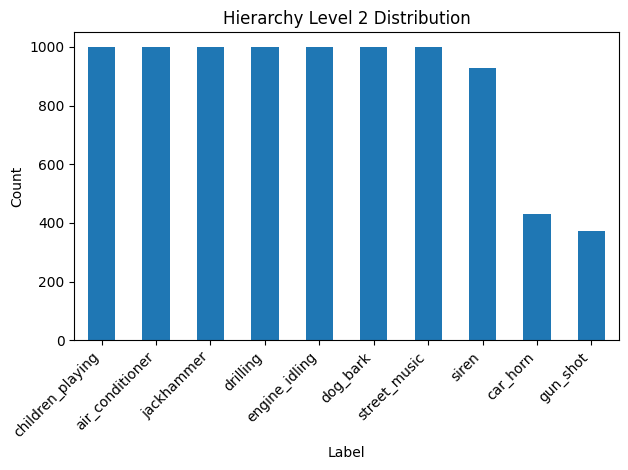

In [10]:
# For URBANSOUND8k
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 (coarse categories)
counts_lvl0 = count_by_hierarchy_level(df, level=0, normalized=False)
print(counts_lvl0)
plot_hierarchy_distribution(counts_lvl0, level=0)

# Level 1 (mid labels)
counts_lvl1 = count_by_hierarchy_level(df, level=1, normalized=False)
print(counts_lvl1)
plot_hierarchy_distribution(counts_lvl1, level=1)

# Level 2 (fine labels)
counts_lvl2 = count_by_hierarchy_level(df, level=2, normalized=False)
print(counts_lvl2)
plot_hierarchy_distribution(counts_lvl2, level=2)

This section below allows for stacked distribution tables:

child         air_conditioner  car_horn  children_playing  dog_bark  drilling  \
parent                                                                          
human_animal                0         0              1000      1000         0   
impact                      0         0                 0         0         0   
mechanical               1000         0                 0         0      1000   
vehicle                     0       429                 0         0         0   

child         engine_idling  gun_shot  jackhammer  siren  street_music  
parent                                                                  
human_animal              0         0           0      0          1000  
impact                    0       374           0      0             0  
mechanical                0         0        1000      0             0  
vehicle                1000         0           0    929             0  


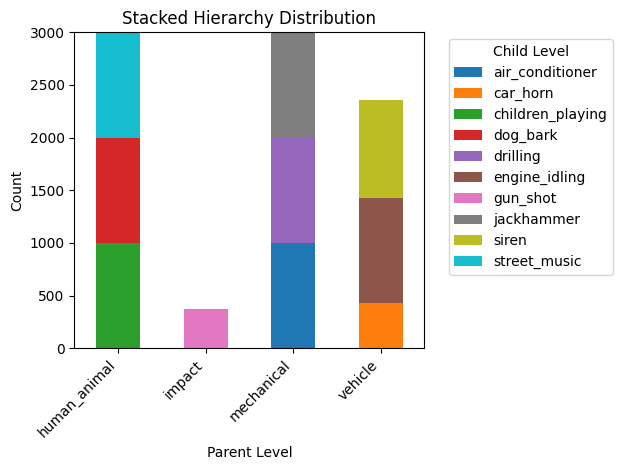

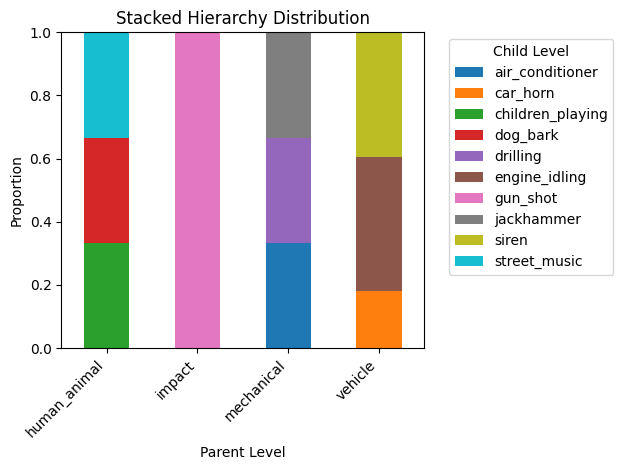

In [11]:
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 → Level 1
pivot = stacked_distribution(df, level_parent=0, level_child=2)

print(pivot)

plot_stacked_distribution(pivot, normalize=False)   # raw counts
plot_stacked_distribution(pivot, normalize=True)    # proportions

Alternatively, you could also make a "Sunburst" plot..

### Signal Processing

#### Theoretic notes (Draft)

In [ ]:
"""
Waveform:
|------n_fft------|
[Frame 1]
        |------n_fft------|
        [Frame 2]
                |------n_fft------|
                [Frame 3]

- The width of each window = n_fft

- The step between windows = hop_length

- Due to the Newquist Rate = (f_s / 2), the frequency range of the spectrogram will always be
  constrained to the length of the sample width [0Hz, f_s / 2]. 
  The Nyquist rate sets the maximum frequency you can represent.

"""

#### Utility functions for Audio processing

In [12]:
def extract_features(y, sr, mode="Mel", n_fft=2048, hop_length=512, n_mels=128, n_mfcc=20):
    """
    y       :  audio time-series, np.ndarray [shape=(..., n)]
    sr      :  sampling rate, number > 0 [scalar]
    mode    :  spectrogram representation, [string]

    returns :
      np.ndarray
      - "STFT": dB magnitude spectrogram shape (n_fft/2+1, t)
      - "Mel": dB mel spectrogram shape (128, t)
      - "MFCCs": MFCC matrix shape (20, t)

    NOTE: 
        n_mels or n_mfcc: controls number of mel bands (i.e., frequency bins after mel filterbank).
    """

    if mode == "STFT":
        S = np.abs(librosa.stft(y))
        return librosa.amplitude_to_db(S, n_fft=n_fft, hop_length=hop_length, ref=np.max)

    elif mode == "Mel":
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        return librosa.power_to_db(S, ref=np.max)

    elif mode == "MFCCs":
        return librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc)


def plot_spectrogram(S_db, sr, hop_length=512, mode="Mel", cmap="viridis"):
    """
    S_db   : np.ndarray feature matrix in dB (output of extract_features)
    sr     : sample rate
    hop_length: hop length used for STFT/mel (same as used for compute)
    mode   : "STFT" | "Mel" | "MFCCs"
    """
    if mode == "Mel":
        y_axis = "mel"
    elif mode == "STFT":
        y_axis = "linear"
    elif mode == "MFCCs":
        y_axis = "mel"   # any order axis works; MFCC is not freq axis but frame x coef
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        fmin=0,
        fmax= sr / 2, # Nyquist sampling theorem
        cmap=cmap,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{mode} spectrogram (dB)")
    plt.tight_layout()
    plt.show()

#### (Example) Plotting the spectrogram of Sound Data

In [9]:
example_clip = dataset.choice_clip()  # choose a random example clip
# print(example_clip)  # see the available data

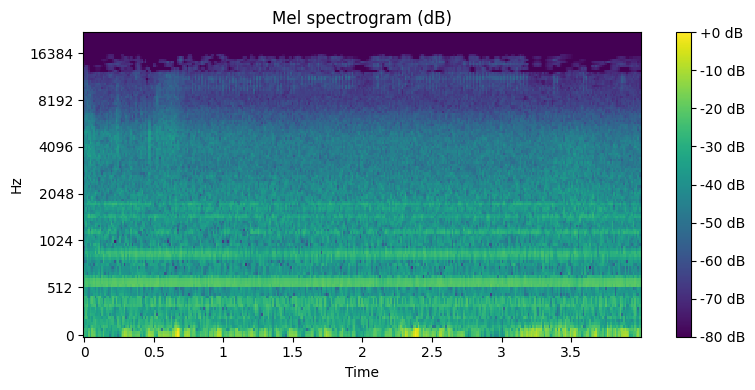

In [68]:
n_fft = 1024
hop_len = 512

# Plot Spectrogram
S_F = extract_features(*example_clip.audio, mode=SPECTROGRAM_METHOD, n_fft=n_fft, hop_length=hop_len)
plot_spectrogram(S_F, example_clip.audio[1], hop_length=hop_len, mode=SPECTROGRAM_METHOD, cmap="viridis")

#### Data Augmentation

## Section 2: Model

In [13]:
import torch